# 06d — CLEAR VAE vs Direct CLEAR Comparison

## Confronto finale dell'estensione VAE

Questo notebook confronta due strategie di ricerca controfattuale applicate allo stesso seed peptidico e allo stesso oracle 04d:

### Direct CLEAR — 04e
Ottimizzazione diretta nello spazio categoriale / delle trasformazioni amminoacidiche.

### VAE-CLEAR — 06c
Ottimizzazione del codice latente continuo appreso dal VAE:

\[
F0010 \rightarrow z_{seed} \rightarrow z_{cf}
\rightarrow Decoder(z_{cf})
\rightarrow peptide
\]

La Pipeline 2 consolidata non viene modificata.

```text
Pipeline 2:
04c → 04d → 04e → 05c → 05d → 05e

VAE extension:
06a → 06b → 06c → 06d
```

## Obiettivi

1. misurare l'overlap tra Direct CLEAR e VAE-CLEAR;
2. verificare se entrambi recuperano le stesse mutazioni dominanti;
3. confrontare miglioramento oracle e minimalità;
4. integrare, quando disponibili, FoldX, FlexPepDock e adjacent-pair score;
5. distinguere chiaramente candidati già strutturalmente valutati da candidati VAE-only;
6. stabilire quale valore metodologico aggiunge il VAE.


## 1. Dipendenze

In [1]:
from pathlib import Path
from collections import Counter
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 180)

OUTPUT_DIR = Path("outputs")

RESULT_DIR = (
    OUTPUT_DIR
    / "clear_vae_vs_direct_comparison_06d"
)

REPORTS_DIR = RESULT_DIR / "reports"

for directory in [RESULT_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SEED_ID = "F0010"
SEED_SEQUENCE = "IGERCQYRDLK"

print("Output:", RESULT_DIR.resolve())

Output: /Users/robertobruzzese/Desktop/venv/outputs/clear_vae_vs_direct_comparison_06d


## 2. Percorsi degli artefatti

In [2]:
DIRECT_CLEAR_DIR = (
    OUTPUT_DIR
    / "clear_peptide_counterfactuals_04e"
)

DIRECT_RANKING_CSV = (
    DIRECT_CLEAR_DIR
    / "clear_counterfactual_final_ranking.csv"
)

DIRECT_VALIDATION_CSV = (
    DIRECT_CLEAR_DIR
    / "validation_panel"
    / "clear_counterfactual_validation_panel.csv"
)

VAE_CLEAR_DIR = (
    OUTPUT_DIR
    / "clear_peptide_vae_counterfactuals_06c"
)

VAE_SUCCESSFUL_CSV = (
    VAE_CLEAR_DIR
    / "vae_clear_successful_candidates.csv"
)

VAE_PANEL_CSV = (
    VAE_CLEAR_DIR
    / "vae_clear_validation_panel.csv"
)

FOLDX_05C_CSV = (
    OUTPUT_DIR
    / "clear_counterfactual_validation_05c"
    / "clear_counterfactual_foldx_structural_validation.csv"
)

ROSETTA_05D_CSV = (
    OUTPUT_DIR
    / "clear_counterfactual_flexpepdock_05d"
    / "clear_counterfactual_flexpepdock_final_ranking.csv"
)

PAIR_05E_DIR = (
    OUTPUT_DIR
    / "clear_adjacent_pair_scoring_05e"
)

PAIR_MATRIX_CSV = (
    PAIR_05E_DIR
    / "adjacent_pair_score_matrix.csv"
)

PAIR_INTEGRATED_CSV = (
    PAIR_05E_DIR
    / "pair_scores_with_foldx_rosetta.csv"
)

PAIR_CANDIDATE_CSV = (
    PAIR_05E_DIR
    / "candidate_pairwise_scores.csv"
)

for name, path in {
    "Direct ranking": DIRECT_RANKING_CSV,
    "Direct validation": DIRECT_VALIDATION_CSV,
    "VAE successful": VAE_SUCCESSFUL_CSV,
    "VAE panel": VAE_PANEL_CSV,
    "FoldX 05c": FOLDX_05C_CSV,
    "Rosetta 05d": ROSETTA_05D_CSV,
    "Pair matrix 05e": PAIR_MATRIX_CSV,
    "Pair integrated 05e": PAIR_INTEGRATED_CSV,
}.items():
    print(
        f"{name:20s}",
        "FOUND" if path.exists() else "missing",
        "->",
        path,
    )

Direct ranking       FOUND -> outputs/clear_peptide_counterfactuals_04e/clear_counterfactual_final_ranking.csv
Direct validation    FOUND -> outputs/clear_peptide_counterfactuals_04e/validation_panel/clear_counterfactual_validation_panel.csv
VAE successful       FOUND -> outputs/clear_peptide_vae_counterfactuals_06c/vae_clear_successful_candidates.csv
VAE panel            FOUND -> outputs/clear_peptide_vae_counterfactuals_06c/vae_clear_validation_panel.csv
FoldX 05c            FOUND -> outputs/clear_counterfactual_validation_05c/clear_counterfactual_foldx_structural_validation.csv
Rosetta 05d          FOUND -> outputs/clear_counterfactual_flexpepdock_05d/clear_counterfactual_flexpepdock_final_ranking.csv
Pair matrix 05e      FOUND -> outputs/clear_adjacent_pair_scoring_05e/adjacent_pair_score_matrix.csv
Pair integrated 05e  FOUND -> outputs/clear_adjacent_pair_scoring_05e/pair_scores_with_foldx_rosetta.csv


## 3. Caricamento Direct CLEAR e VAE-CLEAR

Il confronto principale usa le sequenze effettivamente ottenute dai due metodi.

Se il ranking completo 04e non è disponibile, viene usato il pannello di validazione.


In [3]:
def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


direct_path = first_existing([
    DIRECT_RANKING_CSV,
    DIRECT_VALIDATION_CSV,
])

vae_path = first_existing([
    VAE_SUCCESSFUL_CSV,
    VAE_PANEL_CSV,
])

if direct_path is None:
    raise FileNotFoundError(
        "Output Direct CLEAR 04e non trovato."
    )

if vae_path is None:
    raise FileNotFoundError(
        "Output VAE-CLEAR 06c non trovato."
    )

direct_raw = pd.read_csv(direct_path)
vae_raw = pd.read_csv(vae_path)

print("Direct source:", direct_path.resolve())
print("VAE source:", vae_path.resolve())
print("Direct rows:", len(direct_raw))
print("VAE rows:", len(vae_raw))

Direct source: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_counterfactuals_04e/clear_counterfactual_final_ranking.csv
VAE source: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_counterfactuals_06c/vae_clear_successful_candidates.csv
Direct rows: 36
VAE rows: 4


## 4. Normalizzazione delle colonne

In [4]:
def pick_column(df, candidates):
    return next(
        (
            column
            for column in candidates
            if column in df.columns
        ),
        None,
    )


direct_sequence_col = pick_column(
    direct_raw,
    [
        "sequence",
        "peptide_sequence",
        "mutant_sequence",
    ],
)

direct_mutation_col = pick_column(
    direct_raw,
    [
        "mutation_labels",
        "mutations",
    ],
)

direct_prediction_col = pick_column(
    direct_raw,
    [
        "prediction",
        "oracle_prediction",
    ],
)

direct_improvement_col = pick_column(
    direct_raw,
    [
        "predicted_improvement_vs_seed",
        "oracle_improvement",
    ],
)

direct_id_col = pick_column(
    direct_raw,
    [
        "validation_id",
        "candidate_id",
        "cf_id",
    ],
)

vae_sequence_col = pick_column(
    vae_raw,
    [
        "sequence",
        "peptide_sequence",
    ],
)

vae_mutation_col = pick_column(
    vae_raw,
    [
        "mutations",
        "mutation_labels",
    ],
)

vae_prediction_col = pick_column(
    vae_raw,
    [
        "oracle_prediction",
        "prediction",
    ],
)

vae_improvement_col = pick_column(
    vae_raw,
    [
        "oracle_improvement",
        "predicted_improvement_vs_seed",
    ],
)

vae_id_col = pick_column(
    vae_raw,
    [
        "vae_cf_id",
        "candidate_id",
    ],
)

for required_name, value in {
    "direct sequence": direct_sequence_col,
    "direct prediction": direct_prediction_col,
    "direct improvement": direct_improvement_col,
    "VAE sequence": vae_sequence_col,
    "VAE prediction": vae_prediction_col,
    "VAE improvement": vae_improvement_col,
}.items():
    if value is None:
        raise ValueError(
            f"Colonna non individuata: {required_name}"
        )


direct = pd.DataFrame({
    "sequence": (
        direct_raw[direct_sequence_col]
        .astype(str)
        .str.strip()
        .str.upper()
    ),
    "direct_id": (
        direct_raw[direct_id_col]
        if direct_id_col
        else pd.Series(
            [
                f"DIRECT_{i+1:03d}"
                for i in range(len(direct_raw))
            ]
        )
    ),
    "direct_mutations": (
        direct_raw[direct_mutation_col]
        if direct_mutation_col
        else np.nan
    ),
    "direct_oracle": (
        direct_raw[direct_prediction_col]
    ),
    "direct_improvement": (
        direct_raw[direct_improvement_col]
    ),
})

vae = pd.DataFrame({
    "sequence": (
        vae_raw[vae_sequence_col]
        .astype(str)
        .str.strip()
        .str.upper()
    ),
    "vae_id": (
        vae_raw[vae_id_col]
        if vae_id_col
        else pd.Series(
            [
                f"VAE_{i+1:03d}"
                for i in range(len(vae_raw))
            ]
        )
    ),
    "vae_mutations": (
        vae_raw[vae_mutation_col]
        if vae_mutation_col
        else np.nan
    ),
    "vae_oracle": (
        vae_raw[vae_prediction_col]
    ),
    "vae_improvement": (
        vae_raw[vae_improvement_col]
    ),
})

if "latent_radius" in vae_raw.columns:
    vae["latent_radius"] = (
        vae_raw["latent_radius"]
    )

if "seen_in_04c" in vae_raw.columns:
    vae["seen_in_04c"] = (
        vae_raw["seen_in_04c"]
    )

direct = (
    direct.drop_duplicates("sequence")
    .reset_index(drop=True)
)

vae = (
    vae.drop_duplicates("sequence")
    .reset_index(drop=True)
)

display(direct.head(20))
display(vae.head(20))

,sequence,direct_id,direct_mutations,direct_oracle,direct_improvement
0,IGERSQYRELK,DIRECT_001,C5S;D9E,0.841685,0.095755
1,IGERCQYRELK,DIRECT_002,D9E,0.808901,0.062971
2,IGERCQYKELK,DIRECT_003,R8K;D9E,0.820839,0.074910
3,IGERCEYRELK,DIRECT_004,Q6E;D9E,0.820120,0.074191
4,IGERCQYRELR,DIRECT_005,D9E;K11R,0.813354,0.067425
5,IGERCQYRELE,DIRECT_006,D9E;K11E,0.807465,0.061535
6,IGERSEYRDLK,DIRECT_007,C5S;Q6E,0.807358,0.061428
7,IGERSQYRDLK,DIRECT_008,C5S,0.778680,0.032750
8,IGERCQYRELQ,DIRECT_009,D9E;K11Q,0.803391,0.057461
9,IGERSQYKDLK,DIRECT_010,C5S;R8K,0.794216,0.048286


,sequence,vae_id,vae_mutations,vae_oracle,vae_improvement,latent_radius,seen_in_04c
0,IGERSQYRELK,VAE_001,C5S;D9E,0.841685,0.095755,0.988967,True
1,IGERCQYRELK,VAE_002,D9E,0.808900,0.062971,0.654068,True
2,IGERCQYREMK,VAE_003,D9E;L10M,0.788094,0.042164,1.716511,True
3,IGERSQYRDLK,VAE_004,C5S,0.778680,0.032750,0.419940,True


## 5. Distanza di Hamming e minimalità

In [5]:
def hamming_distance(seq_a, seq_b):
    return sum(
        aa != bb
        for aa, bb in zip(seq_a, seq_b)
    )


def mutation_notation(sequence):
    changes = []

    for position, (
        wt,
        mut,
    ) in enumerate(
        zip(
            SEED_SEQUENCE,
            sequence,
        ),
        start=1,
    ):
        if wt != mut:
            changes.append(
                f"{wt}{position}{mut}"
            )

    return (
        ";".join(changes)
        if changes
        else "seed"
    )


direct["n_mutations"] = (
    direct["sequence"]
    .apply(
        lambda seq:
        hamming_distance(
            seq,
            SEED_SEQUENCE,
        )
    )
)

vae["n_mutations"] = (
    vae["sequence"]
    .apply(
        lambda seq:
        hamming_distance(
            seq,
            SEED_SEQUENCE,
        )
    )
)

direct["mutation_signature"] = (
    direct["sequence"]
    .apply(mutation_notation)
)

vae["mutation_signature"] = (
    vae["sequence"]
    .apply(mutation_notation)
)

## 6. Overlap tra i due metodi

In [6]:
direct_set = set(
    direct["sequence"]
)

vae_set = set(
    vae["sequence"]
)

shared_set = (
    direct_set
    & vae_set
)

union_set = (
    direct_set
    | vae_set
)

jaccard = (
    len(shared_set)
    / len(union_set)
    if union_set
    else np.nan
)

vae_recovery_of_direct = (
    len(shared_set)
    / len(direct_set)
    if direct_set
    else np.nan
)

direct_recovery_of_vae = (
    len(shared_set)
    / len(vae_set)
    if vae_set
    else np.nan
)

method_summary = pd.DataFrame([
    {
        "metric": "Direct CLEAR unique candidates",
        "value": len(direct_set),
    },
    {
        "metric": "VAE-CLEAR unique candidates",
        "value": len(vae_set),
    },
    {
        "metric": "Shared sequences",
        "value": len(shared_set),
    },
    {
        "metric": "Jaccard sequence overlap",
        "value": jaccard,
    },
    {
        "metric": "VAE recovery of Direct",
        "value": vae_recovery_of_direct,
    },
    {
        "metric": "Direct recovery of VAE",
        "value": direct_recovery_of_vae,
    },
])

display(method_summary)

print("Shared sequences:")
for sequence in sorted(shared_set):
    print(
        sequence,
        mutation_notation(sequence),
    )

,metric,value
0,Direct CLEAR unique candidates,36.000000
1,VAE-CLEAR unique candidates,4.000000
2,Shared sequences,4.000000
3,Jaccard sequence overlap,0.111111
4,VAE recovery of Direct,0.111111
5,Direct recovery of VAE,1.000000


Shared sequences:
IGERCQYRELK D9E
IGERCQYREMK D9E;L10M
IGERSQYRDLK C5S
IGERSQYRELK C5S;D9E


## 7. Tabella unificata dei candidati

Ogni sequenza viene classificata come:

- `shared`: recuperata da entrambi i metodi;
- `direct_only`: ottenuta solo dal Direct CLEAR;
- `vae_only`: ottenuta solo dal VAE-CLEAR.


In [7]:
all_sequences = sorted(
    union_set
)

rows = []

direct_index = (
    direct.set_index("sequence")
)

vae_index = (
    vae.set_index("sequence")
)

for sequence in all_sequences:
    in_direct = (
        sequence in direct_set
    )
    in_vae = (
        sequence in vae_set
    )

    if in_direct and in_vae:
        origin = "shared"
    elif in_direct:
        origin = "direct_only"
    else:
        origin = "vae_only"

    row = {
        "sequence": sequence,
        "mutations": mutation_notation(
            sequence
        ),
        "n_mutations": hamming_distance(
            sequence,
            SEED_SEQUENCE,
        ),
        "origin": origin,
        "in_direct": in_direct,
        "in_vae": in_vae,
    }

    if in_direct:
        d = direct_index.loc[
            sequence
        ]
        row.update({
            "direct_id": d[
                "direct_id"
            ],
            "direct_oracle": float(
                d[
                    "direct_oracle"
                ]
            ),
            "direct_improvement": float(
                d[
                    "direct_improvement"
                ]
            ),
        })

    if in_vae:
        v = vae_index.loc[
            sequence
        ]
        row.update({
            "vae_id": v[
                "vae_id"
            ],
            "vae_oracle": float(
                v[
                    "vae_oracle"
                ]
            ),
            "vae_improvement": float(
                v[
                    "vae_improvement"
                ]
            ),
        })

        if "latent_radius" in vae.columns:
            row["latent_radius"] = float(
                v["latent_radius"]
            )

    rows.append(row)

comparison = pd.DataFrame(
    rows
)

comparison["oracle_best_available"] = (
    comparison[
        [
            column
            for column in [
                "direct_oracle",
                "vae_oracle",
            ]
            if column
            in comparison.columns
        ]
    ].max(axis=1)
)

comparison[
    "improvement_best_available"
] = (
    comparison[
        [
            column
            for column in [
                "direct_improvement",
                "vae_improvement",
            ]
            if column
            in comparison.columns
        ]
    ].max(axis=1)
)

display(
    comparison.sort_values(
        "improvement_best_available",
        ascending=False,
    )
)

,sequence,mutations,n_mutations,origin,in_direct,in_vae,direct_id,direct_oracle,direct_improvement,vae_id,vae_oracle,vae_improvement,latent_radius,oracle_best_available,improvement_best_available
28,IGERSQYRELK,C5S;D9E,2,shared,True,True,DIRECT_001,0.841685,0.095755,VAE_001,0.841685,0.095755,0.988967,0.841685,0.095755
10,IGERCQYKELK,R8K;D9E,2,direct_only,True,False,DIRECT_003,0.820839,0.074910,NaN,NaN,NaN,NaN,0.820839,0.074910
4,IGERCEYRELK,Q6E;D9E,2,direct_only,True,False,DIRECT_004,0.820120,0.074191,NaN,NaN,NaN,NaN,0.820120,0.074191
18,IGERCQYRELR,D9E;K11R,2,direct_only,True,False,DIRECT_005,0.813354,0.067425,NaN,NaN,NaN,NaN,0.813354,0.067425
15,IGERCQYRELK,D9E,1,shared,True,True,DIRECT_002,0.808901,0.062971,VAE_002,0.808900,0.062971,0.654068,0.808901,0.062971
13,IGERCQYRELE,D9E;K11E,2,direct_only,True,False,DIRECT_006,0.807465,0.061535,NaN,NaN,NaN,NaN,0.807465,0.061535
21,IGERSEYRDLK,C5S;Q6E,2,direct_only,True,False,DIRECT_007,0.807358,0.061428,NaN,NaN,NaN,NaN,0.807358,0.061428
17,IGERCQYRELQ,D9E;K11Q,2,direct_only,True,False,DIRECT_009,0.803391,0.057461,NaN,NaN,NaN,NaN,0.803391,0.057461
23,IGERSQYKDLK,C5S;R8K,2,direct_only,True,False,DIRECT_010,0.794216,0.048286,NaN,NaN,NaN,NaN,0.794216,0.048286
31,IGERTQYRELK,C5T;D9E,2,direct_only,True,False,DIRECT_011,0.788197,0.042268,NaN,NaN,NaN,NaN,0.788197,0.042268


## 8. Coerenza dell'oracolo sulle sequenze condivise

In [8]:
shared_comparison = (
    comparison[
        comparison["origin"]
        == "shared"
    ].copy()
)

if not shared_comparison.empty:
    shared_comparison[
        "oracle_difference_direct_minus_vae"
    ] = (
        shared_comparison[
            "direct_oracle"
        ]
        - shared_comparison[
            "vae_oracle"
        ]
    )

    shared_comparison[
        "improvement_difference_direct_minus_vae"
    ] = (
        shared_comparison[
            "direct_improvement"
        ]
        - shared_comparison[
            "vae_improvement"
        ]
    )

display(shared_comparison)

,sequence,mutations,n_mutations,origin,in_direct,in_vae,direct_id,direct_oracle,direct_improvement,vae_id,vae_oracle,vae_improvement,latent_radius,oracle_best_available,improvement_best_available,oracle_difference_direct_minus_vae,improvement_difference_direct_minus_vae
15,IGERCQYRELK,D9E,1,shared,True,True,DIRECT_002,0.808901,0.062971,VAE_002,0.808900,0.062971,0.654068,0.808901,0.062971,5.960464e-08,5.960464e-08
19,IGERCQYREMK,D9E;L10M,2,shared,True,True,DIRECT_012,0.788094,0.042164,VAE_003,0.788094,0.042164,1.716511,0.788094,0.042164,0.000000e+00,0.000000e+00
25,IGERSQYRDLK,C5S,1,shared,True,True,DIRECT_008,0.778680,0.032750,VAE_004,0.778680,0.032750,0.419940,0.778680,0.032750,5.960464e-08,5.960464e-08
28,IGERSQYRELK,C5S;D9E,2,shared,True,True,DIRECT_001,0.841685,0.095755,VAE_001,0.841685,0.095755,0.988967,0.841685,0.095755,0.000000e+00,0.000000e+00


## 9. Integrazione con FoldX 05c

In [9]:
foldx = None

if FOLDX_05C_CSV.exists():
    foldx = pd.read_csv(
        FOLDX_05C_CSV
    )

    foldx_sequence_col = pick_column(
        foldx,
        [
            "sequence",
            "peptide_sequence",
        ],
    )

    foldx_id_col = pick_column(
        foldx,
        [
            "validation_id",
            "candidate_id",
        ],
    )

    foldx_ddg_col = pick_column(
        foldx,
        [
            "foldx_ddG_total_kcal_mol",
            "foldx_ddG_kcal_mol",
            "ddG_kcal_mol",
        ],
    )

    foldx_validation_col = pick_column(
        foldx,
        [
            "validation_score",
            "foldx_validation_score",
        ],
    )

    selected_columns = []

    if foldx_sequence_col:
        selected_columns.append(
            foldx_sequence_col
        )

    if foldx_id_col:
        selected_columns.append(
            foldx_id_col
        )

    if foldx_ddg_col:
        selected_columns.append(
            foldx_ddg_col
        )

    if foldx_validation_col:
        selected_columns.append(
            foldx_validation_col
        )

    foldx_small = (
        foldx[
            selected_columns
        ].copy()
    )

    rename_map = {}

    if foldx_sequence_col:
        rename_map[
            foldx_sequence_col
        ] = "sequence"

    if foldx_id_col:
        rename_map[
            foldx_id_col
        ] = "foldx_candidate_id"

    if foldx_ddg_col:
        rename_map[
            foldx_ddg_col
        ] = "foldx_ddG_kcal_mol"

    if foldx_validation_col:
        rename_map[
            foldx_validation_col
        ] = "foldx_validation_score"

    foldx_small = (
        foldx_small.rename(
            columns=rename_map
        )
    )

    if (
        "sequence"
        not in foldx_small.columns
        and "foldx_candidate_id"
        in foldx_small.columns
    ):
        # Map old candidate IDs back to Direct CLEAR sequences.
        id_to_sequence = (
            direct.dropna(
                subset=["direct_id"]
            )
            .set_index(
                "direct_id"
            )["sequence"]
            .to_dict()
        )

        foldx_small[
            "sequence"
        ] = (
            foldx_small[
                "foldx_candidate_id"
            ].map(
                id_to_sequence
            )
        )

    comparison = (
        comparison.merge(
            foldx_small,
            on="sequence",
            how="left",
        )
    )

    print(
        "FoldX-matched sequences:",
        int(
            comparison[
                "foldx_ddG_kcal_mol"
            ].notna().sum()
        )
        if "foldx_ddG_kcal_mol"
        in comparison.columns
        else 0,
    )
else:
    print("05c FoldX output not available.")

FoldX-matched sequences: 10


## 10. Integrazione con Rosetta FlexPepDock 05d

In [10]:
rosetta = None

if ROSETTA_05D_CSV.exists():
    rosetta = pd.read_csv(
        ROSETTA_05D_CSV
    )

    rosetta_sequence_col = pick_column(
        rosetta,
        [
            "sequence",
            "peptide_sequence",
        ],
    )

    rosetta_id_col = pick_column(
        rosetta,
        [
            "candidate_id",
            "validation_id",
        ],
    )

    rosetta_score_col = pick_column(
        rosetta,
        [
            "rosetta_validation_score",
            "validation_score",
        ],
    )

    best_primary_col = pick_column(
        rosetta,
        [
            "best_primary_score",
            "best_reweighted_sc",
            "best_reweighted_score",
        ],
    )

    top5_col = pick_column(
        rosetta,
        [
            "top5_mean_primary_score",
        ],
    )

    isc_col = pick_column(
        rosetta,
        [
            "best_I_sc",
            "I_sc",
        ],
    )

    selected_columns = [
        column
        for column in [
            rosetta_sequence_col,
            rosetta_id_col,
            rosetta_score_col,
            best_primary_col,
            top5_col,
            isc_col,
        ]
        if column is not None
    ]

    rosetta_small = (
        rosetta[
            selected_columns
        ].copy()
    )

    rename_map = {}

    if rosetta_sequence_col:
        rename_map[
            rosetta_sequence_col
        ] = "sequence"

    if rosetta_id_col:
        rename_map[
            rosetta_id_col
        ] = "rosetta_candidate_id"

    if rosetta_score_col:
        rename_map[
            rosetta_score_col
        ] = "rosetta_validation_score"

    if best_primary_col:
        rename_map[
            best_primary_col
        ] = "best_primary_score"

    if top5_col:
        rename_map[
            top5_col
        ] = "top5_mean_primary_score"

    if isc_col:
        rename_map[
            isc_col
        ] = "best_I_sc"

    rosetta_small = (
        rosetta_small.rename(
            columns=rename_map
        )
    )

    if (
        "sequence"
        not in rosetta_small.columns
        and "rosetta_candidate_id"
        in rosetta_small.columns
    ):
        # 05d IDs correspond to F0010 or Direct CLEAR IDs.
        id_to_sequence = {
            "F0010": SEED_SEQUENCE,
        }

        id_to_sequence.update(
            direct.dropna(
                subset=["direct_id"]
            )
            .set_index(
                "direct_id"
            )["sequence"]
            .to_dict()
        )

        rosetta_small[
            "sequence"
        ] = (
            rosetta_small[
                "rosetta_candidate_id"
            ].map(
                id_to_sequence
            )
        )

    comparison = (
        comparison.merge(
            rosetta_small,
            on="sequence",
            how="left",
        )
    )

    if (
        "rosetta_validation_score"
        in comparison.columns
    ):
        print(
            "Rosetta-matched sequences:",
            int(
                comparison[
                    "rosetta_validation_score"
                ].notna().sum()
            ),
        )
else:
    print("05d Rosetta output not available.")

Rosetta-matched sequences: 5


## 11. Adjacent-pair score 05e per tutte le sequenze

Il pair score viene ricalcolato anche per eventuali candidati `vae_only`.

È lo stesso **surrogate energetic pair cost** del 05e:

- posizione-specifico;
- empirico;
- derivato dal target 04c;
- più basso = più favorevole;
- non è energia fisica in kcal/mol.


In [11]:
def build_pair_scorer(pair_matrix_path):
    pair_statistics = pd.read_csv(
        pair_matrix_path
    )

    required = {
        "pair_position_1based",
        "pair",
        "pair_cost",
    }

    if not required.issubset(
        pair_statistics.columns
    ):
        raise ValueError(
            "Formato pair matrix 05e non riconosciuto."
        )

    lookup = {
        (
            int(row.pair_position_1based),
            str(row.pair),
        ): float(row.pair_cost)
        for row in (
            pair_statistics.itertuples(
                index=False
            )
        )
    }

    def score(sequence):
        costs = []

        for i in range(
            len(sequence) - 1
        ):
            pair = (
                sequence[i:i+2]
            )

            costs.append(
                lookup.get(
                    (i + 1, pair),
                    0.0,
                )
            )

        return float(
            np.mean(costs)
        )

    return score


if PAIR_MATRIX_CSV.exists():
    pair_score = build_pair_scorer(
        PAIR_MATRIX_CSV
    )

    comparison[
        "pair_total_cost"
    ] = comparison[
        "sequence"
    ].apply(
        pair_score
    )

    seed_pair_cost = pair_score(
        SEED_SEQUENCE
    )

    comparison[
        "delta_pair_cost_vs_seed"
    ] = (
        comparison[
            "pair_total_cost"
        ]
        - seed_pair_cost
    )

    print(
        "F0010 pair cost:",
        seed_pair_cost,
    )
else:
    print(
        "05e pair matrix not found; "
        "pair score skipped."
    )

F0010 pair cost: -0.00242698748209089


## 12. Stato della validazione strutturale

In [12]:
comparison[
    "has_foldx"
] = (
    comparison[
        "foldx_ddG_kcal_mol"
    ].notna()
    if "foldx_ddG_kcal_mol"
    in comparison.columns
    else False
)

comparison[
    "has_rosetta"
] = (
    comparison[
        "rosetta_validation_score"
    ].notna()
    if "rosetta_validation_score"
    in comparison.columns
    else False
)

comparison[
    "structural_status"
] = np.select(
    [
        (
            comparison["has_foldx"]
            & comparison["has_rosetta"]
        ),
        comparison["has_foldx"],
    ],
    [
        "FoldX+Rosetta evaluated",
        "FoldX evaluated only",
    ],
    default=(
        "not structurally evaluated"
    ),
)

display(
    comparison[
        [
            "sequence",
            "mutations",
            "origin",
            "structural_status",
        ]
    ]
)

,sequence,mutations,origin,structural_status
0,IGERCEYKDLK,Q6E;R8K,direct_only,FoldX evaluated only
1,IGERCEYRDLE,Q6E;K11E,direct_only,not structurally evaluated
2,IGERCEYRDLK,Q6E,direct_only,not structurally evaluated
3,IGERCEYRDLR,Q6E;K11R,direct_only,not structurally evaluated
4,IGERCEYRELK,Q6E;D9E,direct_only,FoldX+Rosetta evaluated
5,IGERCQFRELK,Y7F;D9E,direct_only,not structurally evaluated
6,IGERCQWRELK,Y7W;D9E,direct_only,not structurally evaluated
7,IGERCQYKDLE,R8K;K11E,direct_only,not structurally evaluated
8,IGERCQYKDLK,R8K,direct_only,not structurally evaluated
9,IGERCQYKDLR,R8K;K11R,direct_only,not structurally evaluated


## 13. Ranking integrato descrittivo

In [13]:
def rank_high(series):
    return series.rank(
        method="average",
        ascending=False,
        na_option="bottom",
    )


def rank_low(series):
    return series.rank(
        method="average",
        ascending=True,
        na_option="bottom",
    )


ranking = comparison.copy()

ranking[
    "rank_oracle"
] = rank_high(
    ranking[
        "improvement_best_available"
    ]
)

ranking[
    "rank_minimality"
] = rank_low(
    ranking[
        "n_mutations"
    ]
)

if "pair_total_cost" in ranking.columns:
    ranking[
        "rank_pair"
    ] = rank_low(
        ranking[
            "pair_total_cost"
        ]
    )

if "foldx_ddG_kcal_mol" in ranking.columns:
    ranking[
        "rank_foldx"
    ] = rank_low(
        ranking[
            "foldx_ddG_kcal_mol"
        ]
    )

if (
    "rosetta_validation_score"
    in ranking.columns
):
    ranking[
        "rank_rosetta"
    ] = rank_high(
        ranking[
            "rosetta_validation_score"
        ]
    )

rank_columns = [
    column
    for column in [
        "rank_oracle",
        "rank_minimality",
        "rank_pair",
        "rank_foldx",
        "rank_rosetta",
    ]
    if column in ranking.columns
]

ranking[
    "mean_available_rank"
] = (
    ranking[
        rank_columns
    ].mean(
        axis=1,
        skipna=True,
    )
)

# Number of independent evidence layers actually available.
ranking[
    "n_evidence_layers"
] = (
    1
    + ranking[
        "has_foldx"
    ].astype(int)
    + ranking[
        "has_rosetta"
    ].astype(int)
    + (
        ranking[
            "pair_total_cost"
        ].notna().astype(int)
        if "pair_total_cost"
        in ranking.columns
        else 0
    )
)

display(
    ranking.sort_values(
        [
            "n_evidence_layers",
            "mean_available_rank",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

,sequence,mutations,n_mutations,origin,in_direct,in_vae,direct_id,direct_oracle,direct_improvement,vae_id,vae_oracle,vae_improvement,latent_radius,oracle_best_available,improvement_best_available,foldx_candidate_id,foldx_ddG_kcal_mol,foldx_validation_score,rosetta_candidate_id,rosetta_validation_score,best_primary_score,top5_mean_primary_score,best_I_sc,pair_total_cost,delta_pair_cost_vs_seed,has_foldx,has_rosetta,structural_status,rank_oracle,rank_minimality,rank_pair,rank_foldx,rank_rosetta,mean_available_rank,n_evidence_layers
28,IGERSQYRELK,C5S;D9E,2,shared,True,True,DIRECT_001,0.841685,0.095755,VAE_001,0.841685,0.095755,0.988967,0.841685,0.095755,CF_02,-1.965180,0.750000,CF_02,0.669516,11.860,25.2916,-53.117,-0.042063,-0.039636,True,True,FoldX+Rosetta evaluated,1.0,20.5,3.0,1.0,3.0,5.7,4
4,IGERCEYRELK,Q6E;D9E,2,direct_only,True,False,DIRECT_004,0.820120,0.074191,NaN,NaN,NaN,NaN,0.820120,0.074191,CF_05,-1.767060,0.682180,CF_05,0.448416,17.685,26.4398,-55.303,-0.046202,-0.043775,True,True,FoldX+Rosetta evaluated,3.0,20.5,1.0,3.0,4.0,6.3,4
15,IGERCQYRELK,D9E,1,shared,True,True,DIRECT_002,0.808901,0.062971,VAE_002,0.808900,0.062971,0.654068,0.808901,0.062971,CF_03,-1.802840,0.672702,CF_03,0.182234,25.486,34.0694,-55.304,-0.025227,-0.022800,True,True,FoldX+Rosetta evaluated,5.0,2.5,23.0,2.0,5.0,7.5,4
18,IGERCQYRELR,D9E;K11R,2,direct_only,True,False,DIRECT_005,0.813354,0.067425,NaN,NaN,NaN,NaN,0.813354,0.067425,CF_06,-1.312510,0.587969,CF_06,0.795041,21.476,24.6874,-58.436,-0.030316,-0.027889,True,True,FoldX+Rosetta evaluated,4.0,20.5,10.0,5.0,1.0,8.1,4
17,IGERCQYRELQ,D9E;K11Q,2,direct_only,True,False,DIRECT_009,0.803391,0.057461,NaN,NaN,NaN,NaN,0.803391,0.057461,CF_10,-1.234190,0.559090,CF_10,0.763155,11.173,25.5198,-54.326,-0.027985,-0.025558,True,True,FoldX+Rosetta evaluated,8.0,20.5,13.0,6.0,2.0,9.9,4
10,IGERCQYKELK,R8K;D9E,2,direct_only,True,False,DIRECT_003,0.820839,0.074910,NaN,NaN,NaN,NaN,0.820839,0.074910,CF_04,-1.042900,0.548617,NaN,NaN,NaN,NaN,NaN,-0.031371,-0.028944,True,False,FoldX evaluated only,2.0,20.5,9.0,7.0,21.0,11.9,3
13,IGERCQYRELE,D9E;K11E,2,direct_only,True,False,DIRECT_006,0.807465,0.061535,NaN,NaN,NaN,NaN,0.807465,0.061535,CF_07,-1.549180,0.498492,NaN,NaN,NaN,NaN,NaN,-0.026652,-0.024225,True,False,FoldX evaluated only,6.0,20.5,19.0,4.0,21.0,14.1,3
0,IGERCEYKDLK,Q6E;R8K,2,direct_only,True,False,DIRECT_022,0.772116,0.026186,NaN,NaN,NaN,NaN,0.772116,0.026186,CF_01,0.186924,0.375000,NaN,NaN,NaN,NaN,NaN,-0.045630,-0.043203,True,False,FoldX evaluated only,20.0,20.5,2.0,10.0,21.0,14.7,3
21,IGERSEYRDLK,C5S;Q6E,2,direct_only,True,False,DIRECT_007,0.807358,0.061428,NaN,NaN,NaN,NaN,0.807358,0.061428,CF_08,-0.094799,0.478021,NaN,NaN,NaN,NaN,NaN,-0.026963,-0.024536,True,False,FoldX evaluated only,7.0,20.5,17.0,9.0,21.0,14.9,3
25,IGERSQYRDLK,C5S,1,shared,True,True,DIRECT_008,0.778680,0.032750,VAE_004,0.778680,0.032750,0.419940,0.778680,0.032750,CF_09,-0.340115,0.482393,NaN,NaN,NaN,NaN,NaN,-0.019264,-0.016837,True,False,FoldX evaluated only,16.0,2.5,34.0,8.0,21.0,16.3,3


### Nota importante sul ranking integrato

`mean_available_rank` è una sintesi **descrittiva**, non una nuova misura fisica.

In particolare:

- FoldX e Rosetta hanno significati differenti;
- il pair score non è indipendente dall'oracle, perché deriva dal target locale 04c;
- i candidati VAE-only non devono essere favoriti o penalizzati sulla base di metriche strutturali che non sono state calcolate.

Per questo viene sempre mostrato anche `n_evidence_layers`.


## 14. Mutazioni ricorrenti per metodo

In [14]:
def count_mutations(
    sequences,
):
    counter = Counter()

    for sequence in sequences:
        for position, (
            wt,
            mut,
        ) in enumerate(
            zip(
                SEED_SEQUENCE,
                sequence,
            ),
            start=1,
        ):
            if wt != mut:
                counter[
                    f"{wt}{position}{mut}"
                ] += 1

    return counter


direct_mutations = count_mutations(
    direct["sequence"]
)

vae_mutations = count_mutations(
    vae["sequence"]
)

all_mutations = sorted(
    set(direct_mutations)
    | set(vae_mutations)
)

mutation_comparison = pd.DataFrame({
    "mutation": all_mutations,
    "direct_count": [
        direct_mutations[
            mutation
        ]
        for mutation in all_mutations
    ],
    "vae_count": [
        vae_mutations[
            mutation
        ]
        for mutation in all_mutations
    ],
})

mutation_comparison[
    "shared_mutation"
] = (
    (
        mutation_comparison[
            "direct_count"
        ] > 0
    )
    & (
        mutation_comparison[
            "vae_count"
        ] > 0
    )
)

mutation_comparison = (
    mutation_comparison.sort_values(
        [
            "shared_mutation",
            "direct_count",
            "vae_count",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
)

display(mutation_comparison)

,mutation,direct_count,vae_count,shared_mutation
2,D9E,17,3,True
0,C5S,10,2,True
12,L10M,1,1,True
13,Q6E,7,0,False
14,R8K,7,0,False
7,K11E,5,0,False
11,K11R,4,0,False
3,D9Q,3,0,False
1,C5T,2,0,False
6,I1T,2,0,False


## 15. Grafico: miglioramento oracle per origine

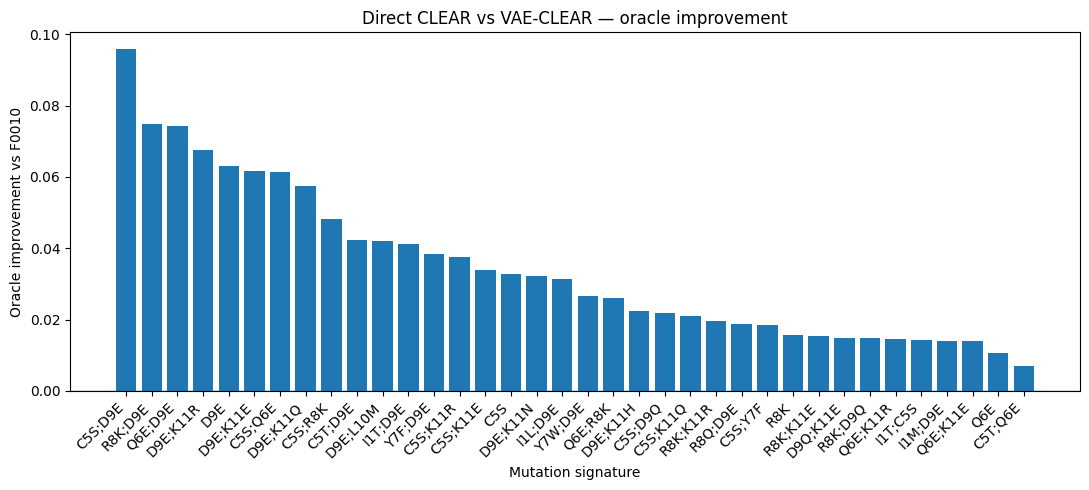

In [15]:
plot_df = (
    comparison.sort_values(
        "improvement_best_available",
        ascending=False,
    )
    .copy()
)

plt.figure(figsize=(11, 5))

plt.bar(
    plot_df["mutations"],
    plot_df[
        "improvement_best_available"
    ],
)

plt.axhline(
    0.0,
    linewidth=1,
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.ylabel(
    "Oracle improvement vs F0010"
)

plt.xlabel(
    "Mutation signature"
)

plt.title(
    "Direct CLEAR vs VAE-CLEAR — oracle improvement"
)

plt.tight_layout()

plt.savefig(
    REPORTS_DIR
    / "oracle_improvement_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 16. Grafico: FoldX vs Rosetta per candidati già valutati

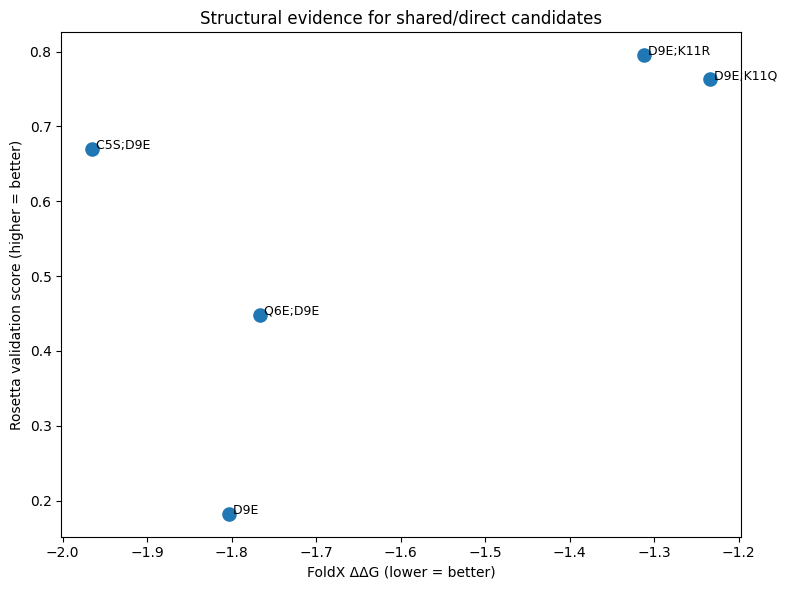

In [16]:
if (
    "foldx_ddG_kcal_mol"
    in comparison.columns
    and
    "rosetta_validation_score"
    in comparison.columns
):
    structural = comparison[
        comparison[
            "foldx_ddG_kcal_mol"
        ].notna()
        &
        comparison[
            "rosetta_validation_score"
        ].notna()
    ].copy()

    if not structural.empty:
        plt.figure(figsize=(8, 6))

        plt.scatter(
            structural[
                "foldx_ddG_kcal_mol"
            ],
            structural[
                "rosetta_validation_score"
            ],
            s=90,
        )

        for _, row in (
            structural.iterrows()
        ):
            plt.text(
                row[
                    "foldx_ddG_kcal_mol"
                ],
                row[
                    "rosetta_validation_score"
                ],
                " "
                + row[
                    "mutations"
                ],
                fontsize=9,
            )

        plt.xlabel(
            "FoldX ΔΔG (lower = better)"
        )

        plt.ylabel(
            "Rosetta validation score (higher = better)"
        )

        plt.title(
            "Structural evidence for shared/direct candidates"
        )

        plt.tight_layout()

        plt.savefig(
            REPORTS_DIR
            / "foldx_vs_rosetta.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

## 17. Analisi dei candidati VAE-only

In [17]:
vae_only = (
    ranking[
        ranking["origin"]
        == "vae_only"
    ]
    .copy()
    .sort_values(
        "vae_improvement",
        ascending=False,
    )
)

if vae_only.empty:
    print(
        "Nessun candidato VAE-only."
    )
else:
    display(
        vae_only[
            [
                column
                for column in [
                    "sequence",
                    "mutations",
                    "n_mutations",
                    "vae_oracle",
                    "vae_improvement",
                    "latent_radius",
                    "pair_total_cost",
                    "delta_pair_cost_vs_seed",
                    "structural_status",
                ]
                if column
                in vae_only.columns
            ]
        ]
    )

    print(
        "Questi candidati NON devono essere "
        "considerati strutturalmente confermati "
        "finché non vengono sottoposti almeno a FoldX."
    )

Nessun candidato VAE-only.


## 18. Convergenza cross-method sui candidati principali

In [18]:
KEY_SEQUENCES = {
    "F0010": "IGERCQYRDLK",
    "C5S+D9E": "IGERSQYRELK",
    "D9E": "IGERCQYRELK",
    "D9E+K11R": "IGERCQYRELR",
    "D9E+K11Q": "IGERCQYRELQ",
    "Q6E+D9E": "IGERCEYRELK",
    "D9E+L10M": "IGERCQYREMK",
    "C5S": "IGERSQYRDLK",
}

key_rows = []

comparison_index = (
    ranking.set_index(
        "sequence"
    )
)

for label, sequence in (
    KEY_SEQUENCES.items()
):
    if sequence in (
        comparison_index.index
    ):
        row = (
            comparison_index.loc[
                sequence
            ]
        )

        key_rows.append({
            "label": label,
            "sequence": sequence,
            "direct": bool(
                row["in_direct"]
            ),
            "vae": bool(
                row["in_vae"]
            ),
            "oracle_improvement": (
                row[
                    "improvement_best_available"
                ]
            ),
            "foldx_ddG": (
                row.get(
                    "foldx_ddG_kcal_mol",
                    np.nan,
                )
            ),
            "rosetta_validation_score": (
                row.get(
                    "rosetta_validation_score",
                    np.nan,
                )
            ),
            "pair_cost": (
                row.get(
                    "pair_total_cost",
                    np.nan,
                )
            ),
            "structural_status": (
                row[
                    "structural_status"
                ]
            ),
        })
    elif label == "F0010":
        key_rows.append({
            "label": label,
            "sequence": sequence,
            "direct": False,
            "vae": False,
            "oracle_improvement": 0.0,
            "foldx_ddG": np.nan,
            "rosetta_validation_score": np.nan,
            "pair_cost": (
                pair_score(sequence)
                if PAIR_MATRIX_CSV.exists()
                else np.nan
            ),
            "structural_status": "reference",
        })

key_candidates = pd.DataFrame(
    key_rows
)

display(key_candidates)

,label,sequence,direct,vae,oracle_improvement,foldx_ddG,rosetta_validation_score,pair_cost,structural_status
0,F0010,IGERCQYRDLK,False,False,0.000000,NaN,NaN,-0.002427,reference
1,C5S+D9E,IGERSQYRELK,True,True,0.095755,-1.965180,0.669516,-0.042063,FoldX+Rosetta evaluated
2,D9E,IGERCQYRELK,True,True,0.062971,-1.802840,0.182234,-0.025227,FoldX+Rosetta evaluated
3,D9E+K11R,IGERCQYRELR,True,False,0.067425,-1.312510,0.795041,-0.030316,FoldX+Rosetta evaluated
4,D9E+K11Q,IGERCQYRELQ,True,False,0.057461,-1.234190,0.763155,-0.027985,FoldX+Rosetta evaluated
5,Q6E+D9E,IGERCEYRELK,True,False,0.074191,-1.767060,0.448416,-0.046202,FoldX+Rosetta evaluated
6,D9E+L10M,IGERCQYREMK,True,True,0.042164,NaN,NaN,-0.017876,not structurally evaluated
7,C5S,IGERSQYRDLK,True,True,0.032750,-0.340115,NaN,-0.019264,FoldX evaluated only


## 19. Interpretazione automatica

In [19]:
shared_sorted = (
    comparison[
        comparison["origin"]
        == "shared"
    ]
    .sort_values(
        "improvement_best_available",
        ascending=False,
    )
)

best_shared = (
    shared_sorted.iloc[0]
    if not shared_sorted.empty
    else None
)

vae_only_sorted = (
    comparison[
        comparison["origin"]
        == "vae_only"
    ]
    .sort_values(
        "vae_improvement",
        ascending=False,
    )
)

best_vae_only = (
    vae_only_sorted.iloc[0]
    if not vae_only_sorted.empty
    else None
)

interpretation_rows = []

if best_shared is not None:
    interpretation_rows.append({
        "finding": "Best cross-method convergence",
        "sequence": best_shared[
            "sequence"
        ],
        "mutations": best_shared[
            "mutations"
        ],
        "meaning": (
            "Recovered by both Direct CLEAR and VAE-CLEAR."
        ),
    })

if best_vae_only is not None:
    interpretation_rows.append({
        "finding": "Best VAE-only candidate",
        "sequence": best_vae_only[
            "sequence"
        ],
        "mutations": best_vae_only[
            "mutations"
        ],
        "meaning": (
            "Generated only by VAE-CLEAR; "
            "requires explicit structural validation."
        ),
    })

if (
    "D9E"
    in set(
        mutation_comparison[
            "mutation"
        ]
    )
):
    d9e_row = (
        mutation_comparison[
            mutation_comparison[
                "mutation"
            ] == "D9E"
        ]
        .iloc[0]
    )

    interpretation_rows.append({
        "finding": "Recurring mutation",
        "sequence": "",
        "mutations": "D9E",
        "meaning": (
            f"Observed in Direct CLEAR count="
            f"{int(d9e_row['direct_count'])} "
            f"and VAE-CLEAR count="
            f"{int(d9e_row['vae_count'])}."
        ),
    })

interpretation_table = pd.DataFrame(
    interpretation_rows
)

display(interpretation_table)

,finding,sequence,mutations,meaning
0,Best cross-method convergence,IGERSQYRELK,C5S;D9E,Recovered by both Direct CLEAR and VAE-CLEAR.
1,Recurring mutation,,D9E,Observed in Direct CLEAR count=17 and VAE-CLEAR count=3.


## 20. Decisione: il VAE aggiunge valore?

In [20]:
n_shared = len(shared_set)
n_vae_only = int(
    (comparison["origin"]
     == "vae_only").sum()
)

n_vae_only_structurally_tested = int(
    (
        (comparison["origin"]
         == "vae_only")
        &
        comparison[
            "has_foldx"
        ]
    ).sum()
)

if n_shared >= 2:
    convergence_value = "YES"
else:
    convergence_value = "LIMITED"

if n_vae_only > 0:
    exploration_value = "YES"
else:
    exploration_value = "NO"

if (
    n_vae_only > 0
    and n_vae_only_structurally_tested
    == 0
):
    next_action = (
        "Validate the best VAE-only candidates "
        "with FoldX before claiming structural added value."
    )
elif n_vae_only > 0:
    next_action = (
        "Compare available structural validation "
        "of VAE-only candidates."
    )
else:
    next_action = (
        "No new VAE-only sequence requires structural validation."
    )

value_assessment = pd.DataFrame([
    {
        "dimension": "Independent convergence",
        "assessment": convergence_value,
        "evidence": (
            f"{n_shared} shared sequence(s)"
        ),
    },
    {
        "dimension": "Additional sequence exploration",
        "assessment": exploration_value,
        "evidence": (
            f"{n_vae_only} VAE-only sequence(s)"
        ),
    },
    {
        "dimension": "Structural added value",
        "assessment": (
            "NOT YET ESTABLISHED"
            if n_vae_only > 0
            and n_vae_only_structurally_tested
            == 0
            else "PARTIALLY ASSESSED"
        ),
        "evidence": (
            f"{n_vae_only_structurally_tested} "
            "VAE-only candidate(s) with FoldX"
        ),
    },
])

display(value_assessment)
print("Recommended next action:", next_action)

,dimension,assessment,evidence
0,Independent convergence,YES,4 shared sequence(s)
1,Additional sequence exploration,NO,0 VAE-only sequence(s)
2,Structural added value,PARTIALLY ASSESSED,0 VAE-only candidate(s) with FoldX


Recommended next action: No new VAE-only sequence requires structural validation.


## 21. Esportazione

In [21]:
COMPARISON_CSV = (
    RESULT_DIR
    / "direct_vs_vae_clear_comparison.csv"
)

RANKING_CSV = (
    RESULT_DIR
    / "integrated_candidate_ranking.csv"
)

METHOD_SUMMARY_CSV = (
    RESULT_DIR
    / "method_overlap_summary.csv"
)

MUTATION_COMPARISON_CSV = (
    RESULT_DIR
    / "mutation_recurrence_by_method.csv"
)

KEY_CANDIDATES_CSV = (
    RESULT_DIR
    / "key_cross_method_candidates.csv"
)

VALUE_ASSESSMENT_CSV = (
    RESULT_DIR
    / "vae_added_value_assessment.csv"
)

comparison.to_csv(
    COMPARISON_CSV,
    index=False,
)

ranking.to_csv(
    RANKING_CSV,
    index=False,
)

method_summary.to_csv(
    METHOD_SUMMARY_CSV,
    index=False,
)

mutation_comparison.to_csv(
    MUTATION_COMPARISON_CSV,
    index=False,
)

key_candidates.to_csv(
    KEY_CANDIDATES_CSV,
    index=False,
)

value_assessment.to_csv(
    VALUE_ASSESSMENT_CSV,
    index=False,
)

for path in [
    COMPARISON_CSV,
    RANKING_CSV,
    METHOD_SUMMARY_CSV,
    MUTATION_COMPARISON_CSV,
    KEY_CANDIDATES_CSV,
    VALUE_ASSESSMENT_CSV,
]:
    print(
        "Salvato:",
        path.resolve(),
    )

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_vae_vs_direct_comparison_06d/direct_vs_vae_clear_comparison.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_vae_vs_direct_comparison_06d/integrated_candidate_ranking.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_vae_vs_direct_comparison_06d/method_overlap_summary.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_vae_vs_direct_comparison_06d/mutation_recurrence_by_method.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_vae_vs_direct_comparison_06d/key_cross_method_candidates.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_vae_vs_direct_comparison_06d/vae_added_value_assessment.csv


## 22. Report automatico finale

In [22]:
shared_labels = [
    mutation_notation(sequence)
    for sequence in sorted(
        shared_set
    )
]

vae_only_labels = (
    comparison.loc[
        comparison["origin"]
        == "vae_only",
        "mutations",
    ].tolist()
)

report = f'''# 06d — CLEAR VAE vs Direct CLEAR Comparison

## Methods
- Direct CLEAR source: `{direct_path}`
- VAE-CLEAR source: `{vae_path}`

## Sequence overlap
- Direct CLEAR unique candidates: {len(direct_set)}
- VAE-CLEAR unique candidates: {len(vae_set)}
- Shared sequences: {len(shared_set)}
- Jaccard overlap: {jaccard:.6f}
- Shared mutation signatures: {", ".join(shared_labels) if shared_labels else "none"}

## VAE-only exploration
- VAE-only sequences: {n_vae_only}
- VAE-only mutation signatures: {", ".join(vae_only_labels) if vae_only_labels else "none"}
- VAE-only with FoldX already available: {n_vae_only_structurally_tested}

## Main methodological conclusion
Direct CLEAR and VAE-CLEAR use different search spaces but the same local peptide problem and the same oracle.

Recovery of the same high-priority sequence by both methods is evidence of algorithmic convergence, not independent biological validation.

The VAE adds methodological value if it:
1. independently recovers robust Direct-CLEAR solutions;
2. explores additional admissible local sequences.

Structural added value can only be claimed for VAE-only candidates after explicit FoldX/Rosetta evaluation.

## Recommended next action
{next_action}

## Important limitation
Oracle, VAE and adjacent-pair score are all learned or derived from the local 04c landscape. Their agreement is not equivalent to independent experimental validation.

FoldX and Rosetta remain separate structural filters, and experimental validation is ultimately required.
'''

REPORT_PATH = (
    REPORTS_DIR
    / "06d_clear_vae_vs_direct_report.md"
)

REPORT_PATH.write_text(
    report,
    encoding="utf-8",
)

print(report)
print(
    "Report:",
    REPORT_PATH.resolve(),
)

# 06d — CLEAR VAE vs Direct CLEAR Comparison

## Methods
- Direct CLEAR source: `outputs/clear_peptide_counterfactuals_04e/clear_counterfactual_final_ranking.csv`
- VAE-CLEAR source: `outputs/clear_peptide_vae_counterfactuals_06c/vae_clear_successful_candidates.csv`

## Sequence overlap
- Direct CLEAR unique candidates: 36
- VAE-CLEAR unique candidates: 4
- Shared sequences: 4
- Jaccard overlap: 0.111111
- Shared mutation signatures: D9E, D9E;L10M, C5S, C5S;D9E

## VAE-only exploration
- VAE-only sequences: 0
- VAE-only mutation signatures: none
- VAE-only with FoldX already available: 0

## Main methodological conclusion
Direct CLEAR and VAE-CLEAR use different search spaces but the same local peptide problem and the same oracle.

Recovery of the same high-priority sequence by both methods is evidence of algorithmic convergence, not independent biological validation.

The VAE adds methodological value if it:
1. independently recovers robust Direct-CLEAR solutions;
2. explores addition

## 23. Conclusione metodologica

Il ramo VAE può essere descritto correttamente come:

```text
04c local peptide landscape
        ↓
06a true VAE
        ↓
06b latent-space validation
        ↓
06c latent counterfactual optimization
        ↓
06d comparison with Direct CLEAR
```

A questo punto è possibile distinguere:

### Convergenza algoritmica
Stessa soluzione recuperata da due metodi di ricerca differenti.

### Esplorazione aggiuntiva
Sequenze ammissibili recuperate solo dal VAE.

### Validazione strutturale
FoldX / FlexPepDock: disponibile solo per i candidati che sono stati realmente sottoposti a tali analisi.

### Validazione biologica
Non ancora effettuata.

La conclusione più forte consentita è quindi una **prioritizzazione computazionale cross-method**, non una dimostrazione di binding o attività inibitoria.
